# Processing Inhibitor Data

____

In [230]:
from pathlib import Path
current_dir = Path().resolve()
from microlive.imports import *
from microlive import microscopy as mi
main_dir = Path().resolve().parent
one_drive_dir = mi.Utilities.get_one_drive_dir()
import inhibitors as INH

## Data Configuration
___

In [231]:
# Loading data
        #RMS External Drive Location:    'E:\Co-translational folding (CoF) paper\Fig 4_Fast_Har analysis'
        #Ning Zhao OneDrive Location:    '...General - Zhao (NZ) Lab\Zhao lab shared folder\Our papers\co-translational folding paper\Fig 4\Fig 4_Harringtonine analysis_GFPFast'


# ── Data Path ─────────────────────────────────────────────
# data_dir = one_drive_dir / 'General - Zhao (NZ) Lab' / 'Gui RMS Analyses' / 'Har' #Onedrive
data_dir = Path(r'E:/Co-translational folding (CoF) paper/Fig 3_Har')
 


# ── Processing Parameters ─────────────────────────────────
inhibitor_frame_index = 4  # 0-indexed: frame when treatment was applied
use_sem = True
show_summary = True
show_individual_trajectories = False
max_percentage_threshold_after_treatment = None #0.5
threshold_percentage_for_runoff = 0.1
use_sigmoidal_fit = True
# ── Plotting Parameters ───────────────────────────────────
figsize = (6, 4)
ylims = (0, 1.4)
xlims = (-5, 6)
results_folder = Path('E:/Co-translational folding (CoF) paper/Fig 3_Har graphs')  # Set to a Path to save plots


## HA Channel (pRS027; 4xGFPfast)
___

── Heaviside Fit ──
  A (amplitude): 0.7063
  T (dwell/run-off time): 16.0872
  C (baseline): 0.0832
  A_err: 0.0312
  T_err: 0.6573
  C_err: 0.0092
  t½:      8.04 min
  τ_runoff (95%): 16.09 min


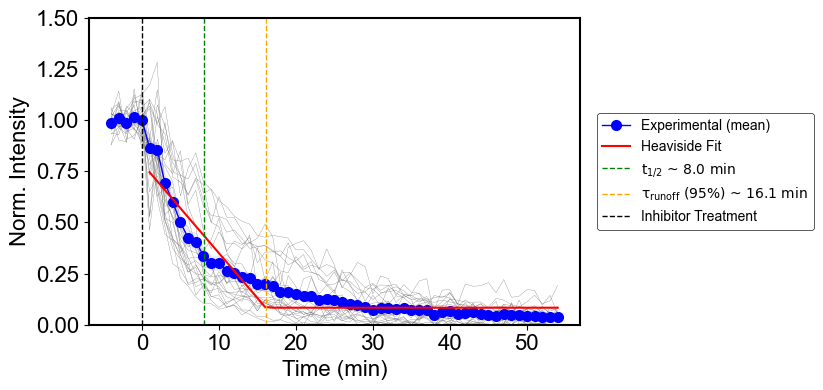

responding_indices_pRS027_HA: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
number of responding trajectories for pRS027_HA: 24


In [232]:
substring_in_data_dir = 'pRS027'
selected_field = 'spot_int_ch_0'
plot_name = 'pRS027_HA'
 
responding_indices_pRS027_HA, frames_pRS027_HA, intensities_pRS027_HA, _, _, _, _, _ = INH.process_inhibitor_data(
    data_dir, inhibitor_frame_index, substring_in_data_dir, selected_field,
    use_sem, show_summary, max_percentage_threshold_after_treatment,remove_frame_at_inhibitor_application=False,
)
 
 
results=INH.plot_inhibitor(
    frames_pRS027_HA,                                # np.ndarray – time array
    intensities_pRS027_HA,                           # np.ndarray – 2D (cells × frames)
    inhibitor_frame_index,                           # int – treatment frame index
    results_folder=results_folder,                   # Path – save location
    plot_name=plot_name,                             # str – filename suffix
    responding_indices=responding_indices_pRS027_HA, # list – which cells to include
    figsize=(6, 4),                                  # tuple
    use_sem=True,                                    # bool – SEM vs SD for error band
    show_individual_trajectories=True,               # bool – gray individual traces
    ylims=(0, 1.5),                                  # tuple – y-axis limits
    y_label='Norm. Intensity',                       # str
    treatment_label='Inhibitor',                     # str – label for treatment line
    show_treatment_line=True,                        # bool – vertical line at t=0
    fit_model='heaviside',                           # 'linear'|'exponential'|'heaviside'|None
    fit_start_idx=inhibitor_frame_index+1,           # int – fit range start (default: inh frame)
    fit_end_idx=None,                                # int – fit range end (default: last frame)
    show_fit=True,                                   # bool – overlay fitted curve
    show_runoff_time=True,                           # bool – draw t½ and τ_runoff lines
    runoff_fraction=0.95,                            # float – threshold for run-off (0.95 = 95%)
)
 
print("responding_indices_pRS027_HA:", responding_indices_pRS027_HA)
print("number of responding trajectories for pRS027_HA:", len(responding_indices_pRS027_HA))
 
 
# Access each dataset by index
#print('run-off time dataset 0:', results['t_runoff'])


# pRS027 Dish 1

── Heaviside Fit ──
  A (amplitude): 0.8104
  T (dwell/run-off time): 10.0331
  C (baseline): 0.0820
  A_err: 0.0342
  T_err: 0.4251
  C_err: 0.0088
  t½:      5.02 min
  τ_runoff (95%): 10.03 min


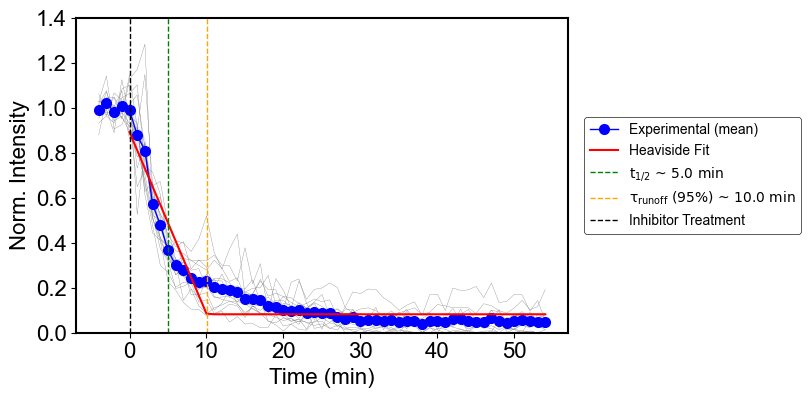

responding_indices_pRS027_Dish2_HA: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
number of responding trajectories for pRS027_Dish2_HA: 14


In [233]:
substring_in_data_dir = 'pRS027_Dish2'
selected_field = 'spot_int_ch_0'
plot_name = 'pRS027_Dish2_HA'

responding_indices_pRS027_Dish2_HA, frames_pRS027_Dish2_HA, intensities_pRS027_Dish2_HA, _, _, _, _, _ = INH.process_inhibitor_data(
    data_dir, inhibitor_frame_index, substring_in_data_dir, selected_field,
    use_sem, show_summary, max_percentage_threshold_after_treatment,
)

INH.plot_inhibitor(
    frames_pRS027_Dish2_HA, intensities_pRS027_Dish2_HA, inhibitor_frame_index,
    show_runoff_time=True,
    plot_name=plot_name,
    fit_model='heaviside',
    #threshold_percentage_for_runoff=threshold_percentage_for_runoff,
    figsize=figsize,
    ylims=ylims,
)

print("responding_indices_pRS027_Dish2_HA:", responding_indices_pRS027_Dish2_HA)
print("number of responding trajectories for pRS027_Dish2_HA:", len(responding_indices_pRS027_Dish2_HA))

# pRS027 Dish 2

── Heaviside Fit ──
  A (amplitude): 0.8049
  T (dwell/run-off time): 23.1532
  C (baseline): 0.0914
  A_err: 0.0301
  T_err: 0.8718
  C_err: 0.0124
  t½:      11.58 min
  τ_runoff (95%): 23.15 min


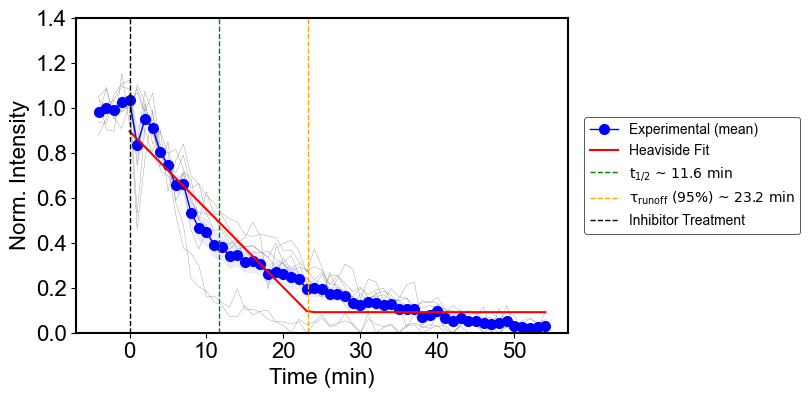

responding_indices_pRS027_Dish3_HA: [0, 1, 2, 3, 4, 5, 6, 7]
number of responding trajectories for pRS027_Dish3_HA: 8


In [234]:
substring_in_data_dir = 'pRS027_Dish3'
selected_field = 'spot_int_ch_0'
plot_name = 'pRS027_Dish3_HA'

responding_indices_pRS027_Dish3_HA, frames_pRS027_Dish3_HA, intensities_pRS027_Dish3_HA, _, _, _, _, _ = INH.process_inhibitor_data(
    data_dir, inhibitor_frame_index, substring_in_data_dir, selected_field,
    use_sem, show_summary, max_percentage_threshold_after_treatment,
)

INH.plot_inhibitor(
    frames_pRS027_Dish3_HA, intensities_pRS027_Dish3_HA, inhibitor_frame_index,
    show_runoff_time=True,
    plot_name=plot_name,
    fit_model='heaviside',
    #threshold_percentage_for_runoff=threshold_percentage_for_runoff,
    figsize=figsize,
    ylims=ylims,
)

print("responding_indices_pRS027_Dish3_HA:", responding_indices_pRS027_Dish3_HA)
print("number of responding trajectories for pRS027_Dish3_HA:", len(responding_indices_pRS027_Dish3_HA))

## HA Channel (pRS032; 4xGFPslow)
___

── Heaviside Fit ──
  A (amplitude): 0.6774
  T (dwell/run-off time): 24.2080
  C (baseline): 0.1674
  A_err: 0.0186
  T_err: 0.6383
  C_err: 0.0074
  t½:      12.10 min
  τ_runoff (95%): 24.21 min


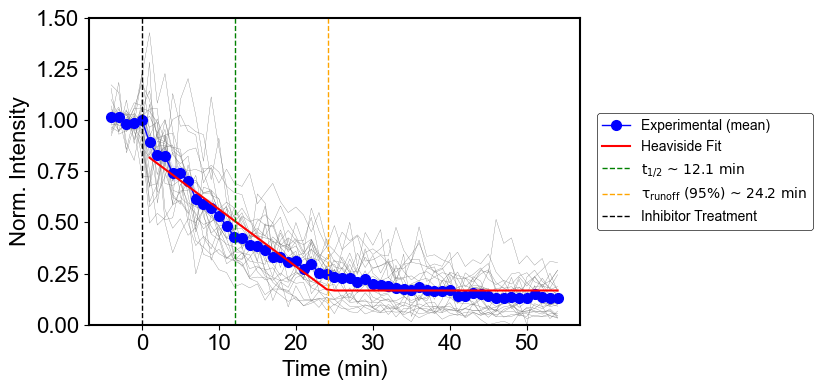

responding_indices_pRS032_HA: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
number of responding trajectories for pRS032_HA: 23


In [235]:
substring_in_data_dir = 'pRS032'
selected_field = 'spot_int_ch_0'
plot_name = 'pRS032_HA'
 
responding_indices_pRS032_HA, frames_pRS032_HA, intensities_pRS032_HA, _, _, _, _, _ = INH.process_inhibitor_data(
    data_dir, inhibitor_frame_index, substring_in_data_dir, selected_field,
    use_sem, show_summary, max_percentage_threshold_after_treatment,remove_frame_at_inhibitor_application=False,
)
 
 
results=INH.plot_inhibitor(
    frames_pRS032_HA,                                # np.ndarray – time array
    intensities_pRS032_HA,                           # np.ndarray – 2D (cells × frames)
    inhibitor_frame_index,                           # int – treatment frame index
    results_folder=results_folder,                   # Path – save location
    plot_name=plot_name,                             # str – filename suffix
    responding_indices=responding_indices_pRS032_HA, # list – which cells to include
    figsize=(6, 4),                                  # tuple
    use_sem=True,                                    # bool – SEM vs SD for error band
    show_individual_trajectories=True,               # bool – gray individual traces
    ylims=(0, 1.5),                                  # tuple – y-axis limits
    y_label='Norm. Intensity',                       # str
    treatment_label='Inhibitor',                     # str – label for treatment line
    show_treatment_line=True,                        # bool – vertical line at t=0
    fit_model='heaviside',                           # 'linear'|'exponential'|'heaviside'|None
    fit_start_idx=inhibitor_frame_index+1,           # int – fit range start (default: inh frame)
    fit_end_idx=None,                                # int – fit range end (default: last frame)
    show_fit=True,                                   # bool – overlay fitted curve
    show_runoff_time=True,                           # bool – draw t½ and τ_runoff lines
    runoff_fraction=0.95,                            # float – threshold for run-off (0.95 = 95%)
)
 
print("responding_indices_pRS032_HA:", responding_indices_pRS032_HA)
print("number of responding trajectories for pRS032_HA:", len(responding_indices_pRS032_HA))

# pRS032 Dish 1

── Heaviside Fit ──
  A (amplitude): 0.7047
  T (dwell/run-off time): 25.4333
  C (baseline): 0.1537
  A_err: 0.0182
  T_err: 0.6719
  C_err: 0.0080
  t½:      12.72 min
  τ_runoff (95%): 25.43 min


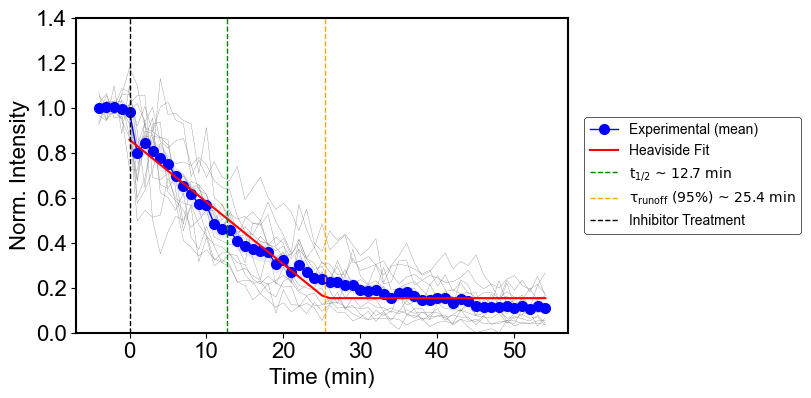

responding_indices_pRS032_Dish1_HA: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
number of responding trajectories for pRS032_Dish1_HA: 13


In [236]:
substring_in_data_dir = 'pRS032_Dish1'
selected_field = 'spot_int_ch_0'
plot_name = 'pRS032_Dish1_HA'

responding_indices_pRS032_Dish1_HA, frames_pRS032_Dish1_HA, intensities_pRS032_Dish1_HA, _, _, _, _, _ = INH.process_inhibitor_data(
    data_dir, inhibitor_frame_index, substring_in_data_dir, selected_field,
    use_sem, show_summary, max_percentage_threshold_after_treatment,
)

INH.plot_inhibitor(
    frames_pRS032_Dish1_HA, intensities_pRS032_Dish1_HA, inhibitor_frame_index,
    show_runoff_time=True,
    plot_name=plot_name,
    fit_model='heaviside',
    #threshold_percentage_for_runoff=threshold_percentage_for_runoff,
    figsize=figsize,
    ylims=ylims,
)

print("responding_indices_pRS032_Dish1_HA:", responding_indices_pRS032_Dish1_HA)
print("number of responding trajectories for pRS032_Dish1_HA:", len(responding_indices_pRS032_Dish1_HA))

# pRS032 Dish 2

── Heaviside Fit ──
  A (amplitude): 0.7198
  T (dwell/run-off time): 20.0196
  C (baseline): 0.1909
  A_err: 0.0238
  T_err: 0.6620
  C_err: 0.0090
  t½:      10.01 min
  τ_runoff (95%): 20.02 min


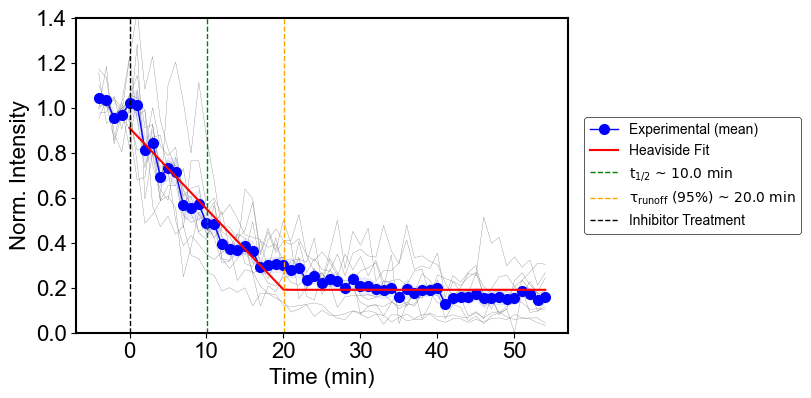

responding_indices_pRS032_Dish2_HA: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
number of responding trajectories for pRS032_Dish2_HA: 10


In [237]:
substring_in_data_dir = 'pRS032_Dish2'
selected_field = 'spot_int_ch_0'
plot_name = 'pRS032_Dish2_HA'

responding_indices_pRS032_Dish2_HA, frames_pRS032_Dish2_HA, intensities_pRS032_Dish2_HA, _, _, _, _, _ = INH.process_inhibitor_data(
    data_dir, inhibitor_frame_index, substring_in_data_dir, selected_field,
    use_sem, show_summary, max_percentage_threshold_after_treatment,
)

INH.plot_inhibitor(
    frames_pRS032_Dish2_HA, intensities_pRS032_Dish2_HA, inhibitor_frame_index,
    show_runoff_time=True,
    plot_name=plot_name,
    fit_model='heaviside',
    #threshold_percentage_for_runoff=threshold_percentage_for_runoff,
    figsize=figsize,
    ylims=ylims,
)

print("responding_indices_pRS032_Dish2_HA:", responding_indices_pRS032_Dish2_HA)
print("number of responding trajectories for pRS032_Dish2_HA:", len(responding_indices_pRS032_Dish2_HA))

## Multi-Reporter Comparison
___

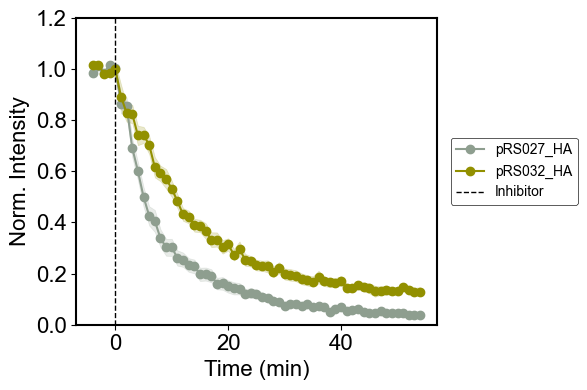

responding_indices_pRS027_HA: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
number of responding trajectories for pRS027_HA: 24
responding_indices_pRS032_HA: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
number of responding trajectories for pRS032_HA: 23


In [238]:
INH.plot_multiple_inhibitors(
    [frames_pRS027_HA, frames_pRS032_HA,],
    [intensities_pRS027_HA, intensities_pRS032_HA],
    inhibitor_frame_index,
    responding_indices_list=[responding_indices_pRS027_HA, responding_indices_pRS032_HA],
    colors=['#8E9E8F', '#929000'],
    legend_labels=['pRS027_HA', 'pRS032_HA'],
    plot_name='HT_multi',
    #threshold_percentage_for_runoff=-0.4,
    ylims = (0, 1.2),
    figsize=figsize,
    use_sem=use_sem,
    show_individual_trajectories=show_individual_trajectories,
    results_folder=results_folder,
)

print("responding_indices_pRS027_HA:", responding_indices_pRS027_HA)
print("number of responding trajectories for pRS027_HA:", len(responding_indices_pRS027_HA))
print("responding_indices_pRS032_HA:", responding_indices_pRS032_HA)
print("number of responding trajectories for pRS032_HA:", len(responding_indices_pRS032_HA))